###Oil Well Data Analysis

In [1]:
#Importing Libraries 
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt #For Visualizing Data
%matplotlib inline 
import seaborn as sns

In [2]:
#Importing Dataset 
df = pd.read_csv('E:\pycharm projects practice\Jupyter Notebook\Diwali Analyst\Oil well.csv')
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_").str.replace("(", "").str.replace(")", "")

In [3]:
#Getting rows and columns info
df.shape

(2939, 9)

In [4]:
#Getting info of 5 rows and columns
df.head()

,date,oil_volume_m3/day,volume_of_liquid_m3/day,gas_volume_m3/day,water_volume_m3/day,water_cut_%,working_hours,dynamic_level_m,reservoir_pressure_atm
0,01-01-2013,49,70,13055,21,29,24,1819,214
1,02-01-2013,49,70,13055,21,29,24,1836,214
2,03-01-2013,49,70,13055,21,29,24,1788,214
3,04-01-2013,49,70,13055,21,29,24,1789,214
4,05-01-2013,44,70,11768,26,36,24,1825,214


In [5]:
#Dataset Info about its type 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2939 entries, 0 to 2938
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   date                     2939 non-null   object
 1   oil_volume_m3/day        2939 non-null   int64 
 2   volume_of_liquid_m3/day  2939 non-null   int64 
 3   gas_volume_m3/day        2939 non-null   int64 
 4   water_volume_m3/day      2939 non-null   int64 
 5   water_cut_%              2939 non-null   int64 
 6   working_hours            2939 non-null   int64 
 7   dynamic_level_m          2939 non-null   int64 
 8   reservoir_pressure_atm   2939 non-null   int64 
dtypes: int64(8), object(1)
memory usage: 206.8+ KB


In [6]:
#Checking for nul values 
pd.isnull(df).sum()

date                       0
oil_volume_m3/day          0
volume_of_liquid_m3/day    0
gas_volume_m3/day          0
water_volume_m3/day        0
water_cut_%                0
working_hours              0
dynamic_level_m            0
reservoir_pressure_atm     0
dtype: int64

In [7]:
#checking all columns
df.columns

Index(['date', 'oil_volume_m3/day', 'volume_of_liquid_m3/day',
       'gas_volume_m3/day', 'water_volume_m3/day', 'water_cut_%',
       'working_hours', 'dynamic_level_m', 'reservoir_pressure_atm'],
      dtype='object')

###Analytics Part

In [8]:
#Measures total liquid handled by the well (oil + water).
df["total_liquid_rate"] = df["oil_volume_m3/day"] + df["water_volume_m3/day"]

In [9]:
#Percentage of water in total liquid; high water cut may indicate water breakthrough.
df["watercut_calc"] = (df["water_volume_m3/day"] / df["total_liquid_rate"]) * 100

In [10]:
#Ratio of produced gas to produced oil; reservoir drive diagnosis
df["gor"] = df["gas_volume_m3/day"] / df["oil_volume_m3/day"].replace(0, np.nan)

In [11]:
#Useful inverse of GOR for some analyses.(Oil gas ratio)
df["ogr"] = 1 / df["gor"]

In [12]:
#Gas per unit of total liquid; relevant for separator sizing.(Gas Liquid ratio)
df["glr"] = df["gas_volume_m3/day"] / df["total_liquid_rate"].replace(0, np.nan)

In [13]:
#Percent of day the well was producing; helps track downtime.(Uptime)
df["uptime_pct"] = (df["working_hours"] / 24) * 100

In [14]:
#Oil rate adjusted for uptime — allows fair performance comparison(Normalized Oil rate)
df["norm_oil_prod_rate"] = df["oil_volume_m3/day"] / (df["working_hours"] / 24).replace(0, np.nan)

In [15]:
#Daily percentage change in reservoir pressure.(pct means percentage changes from reser pr to another pr)
df["pressure_decline_pct"] = df["reservoir_pressure_atm"].pct_change() * 100

In [16]:
#Tracks total volumes produced over time(Cummalative Production for oil gas and water)
df["cum_oil"] = df["oil_volume_m3/day"].cumsum()
df["cum_gas"] = df["gas_volume_m3/day"].cumsum()
df["cum_water"] = df["water_volume_m3/day"].cumsum()

###Summary Statistics 

In [17]:
print("\n--- Summary Statistics ---")
print(df.describe())


--- Summary Statistics ---
       oil_volume_m3/day  volume_of_liquid_m3/day  gas_volume_m3/day  \
count        2939.000000              2939.000000        2939.000000   
mean           17.624362                59.464103        4730.146308   
std             9.689026                18.634101        2598.888524   
min             0.000000                12.000000           4.000000   
25%            11.000000                50.000000        3041.500000   
50%            15.000000                58.000000        3909.000000   
75%            22.000000                74.000000        5843.500000   
max            49.000000               113.000000       13113.000000   

       water_volume_m3/day  water_cut_%  working_hours  dynamic_level_m  \
count          2939.000000  2939.000000    2939.000000      2939.000000   
mean             41.828853    70.694794      22.344675      1930.383464   
std              13.056625     9.534203       3.039553       114.543752   
min               9.000

### Correlation Heatmap

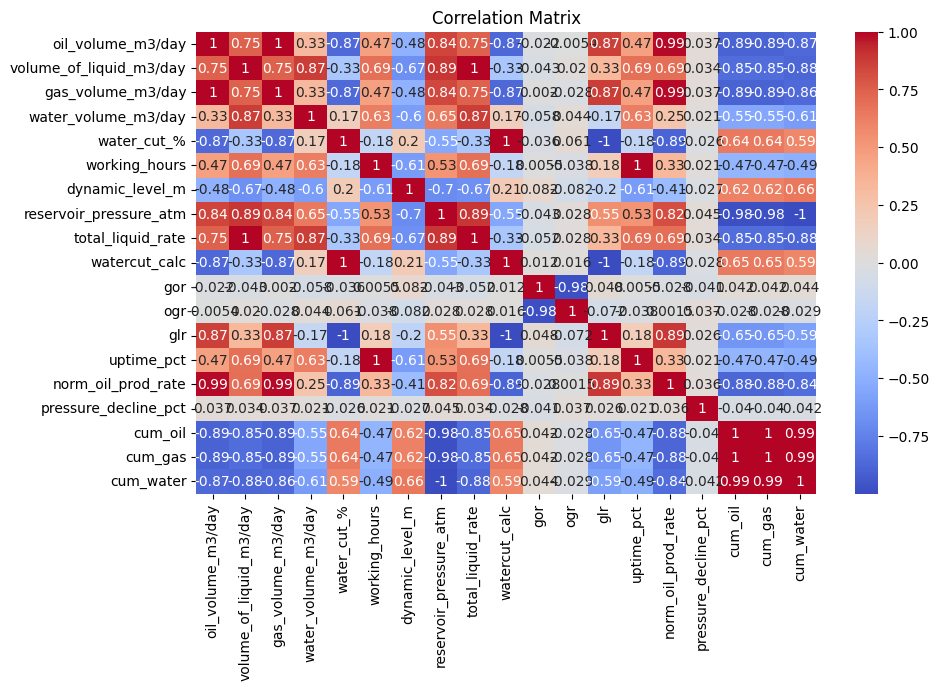

In [18]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()         

###Production Trends

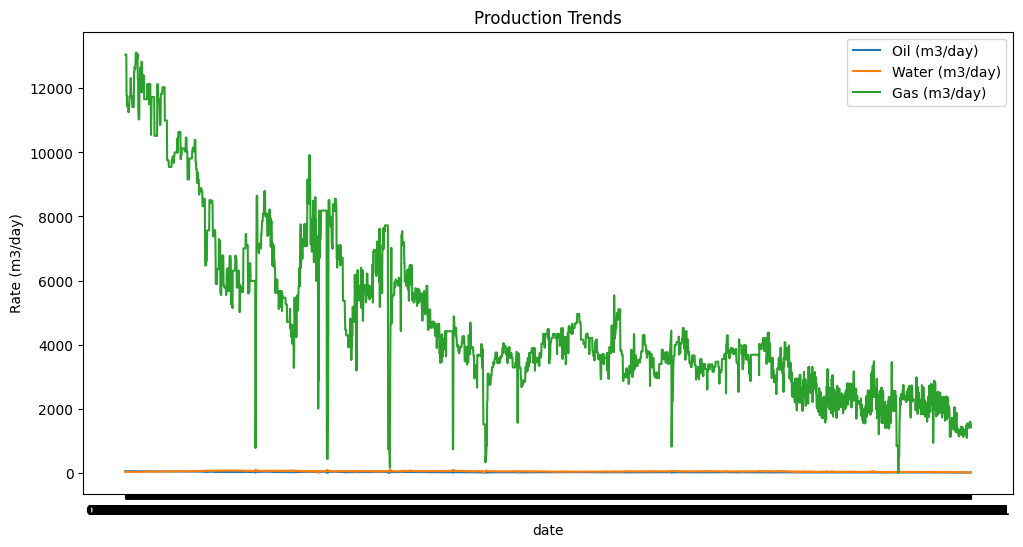

In [19]:
plt.figure(figsize=(12,6))
plt.plot(df["date"], df["oil_volume_m3/day"], label="Oil (m3/day)")
plt.plot(df["date"], df["water_volume_m3/day"], label="Water (m3/day)")
plt.plot(df["date"], df["gas_volume_m3/day"], label="Gas (m3/day)")
plt.xlabel("date")
plt.ylabel("Rate (m3/day)")
plt.title("Production Trends")
plt.legend()
plt.show()

### Water Cut & GOR trends

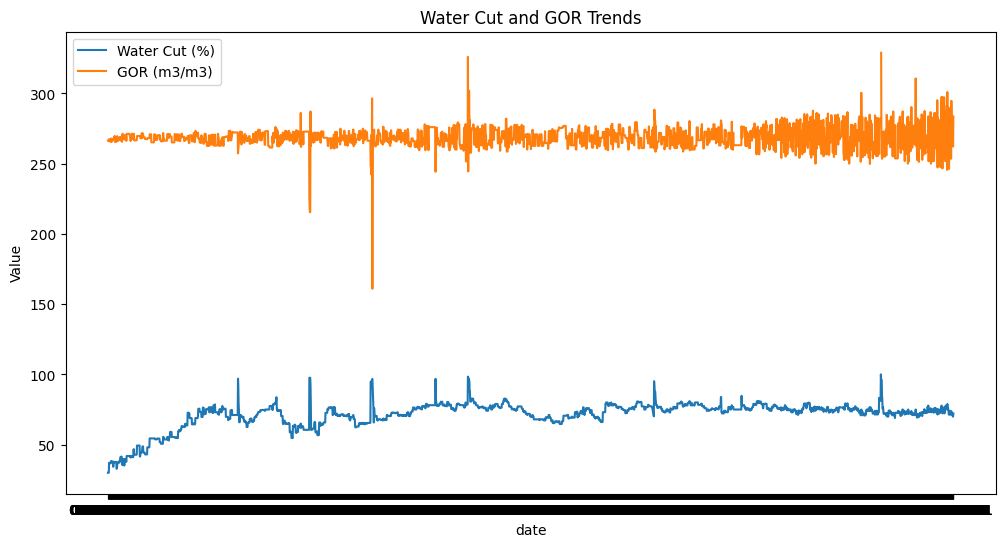

In [20]:
plt.figure(figsize=(12,6))
plt.plot(df["date"], df["watercut_calc"], label="Water Cut (%)")
plt.plot(df["date"], df["gor"], label="GOR (m3/m3)")
plt.xlabel("date")
plt.ylabel("Value")
plt.title("Water Cut and GOR Trends")
plt.legend()
plt.show()

###Reservoir Pressure Trends

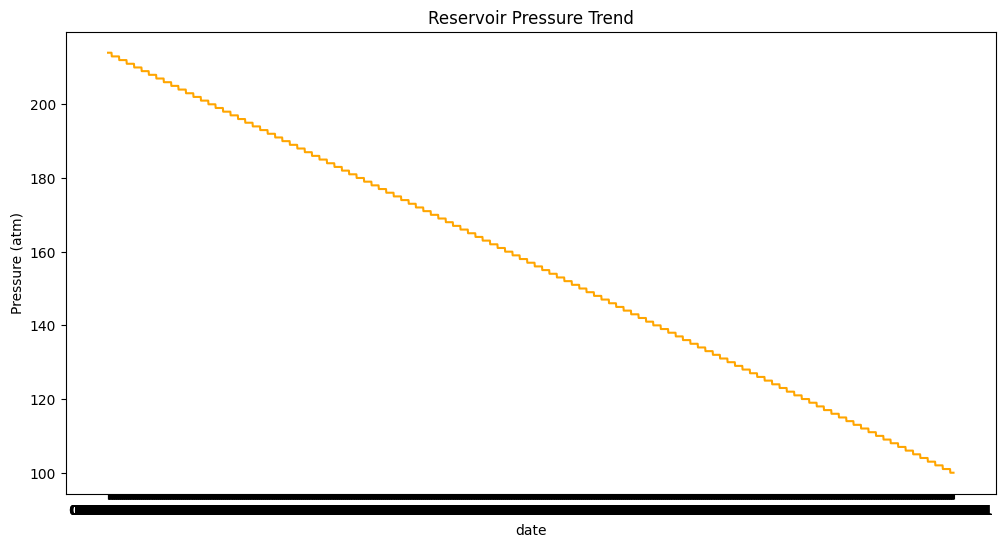

In [21]:
plt.figure(figsize=(12,6))
plt.plot(df["date"], df["reservoir_pressure_atm"], color="orange")
plt.xlabel("date")
plt.ylabel("Pressure (atm)")
plt.title("Reservoir Pressure Trend")
plt.show()

###Anamoly Detection

In [22]:
#Example: High water cut (>90%) or sudden GOR spike
df["watercut_anomaly"] = df["watercut_calc"] > 90
df["gor_anomaly"] = df["gor"].pct_change().abs() > 0.5 #50% jump in GOR

print("\n--- Anomalies ---")
print(df[(df["watercut_anomaly"]) | (df["gor_anomaly"])])


--- Anomalies ---
            date  oil_volume_m3/day  volume_of_liquid_m3/day  \
452   29-03-2014                  3                       98   
453   30-03-2014                  7                       99   
700   02-12-2014                  2                       86   
701   03-12-2014                  2                       83   
702   04-12-2014                  2                       82   
703   05-12-2014                  2                       82   
704   06-12-2014                  6                       82   
913   04-07-2015                  3                       57   
914   05-07-2015                  3                       57   
915   06-07-2015                  3                       55   
916   07-07-2015                  3                       62   
917   08-07-2015                  3                       70   
918   09-07-2015                  2                       56   
919   10-07-2015                  1                       31   
920   11-07-2015     

C:\Users\HP\AppData\Local\Temp\ipykernel_8336\975342983.py:3: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df["gor_anomaly"] = df["gor"].pct_change().abs() > 0.5 #50% jump in GOR


In [ ]:
#saving file
df.to_csv("Oil Well Analysis.csv", index=False)